In [ ]:
import os
print(os.getcwd())
%cd /content

/content/drive/MyDrive/DATA
/content


In [ ]:
from google.colab import drive
drive.flush_and_unmount()

In [ ]:

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd drive/MyDrive/path-prediction/DATA

/content/drive/MyDrive/DATA


In [ ]:
!pip install --quiet pandas scikit-learn tqdm sentence-transformers python-Levenshtein rapidfuzz scikit-learn-extra optuna kmedoids gensim scipy

In [ ]:
import os
import re
import numpy as np
import pandas as pd
from tqdm import tqdm
import optuna

from kmedoids import KMedoids
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

# Пути
INPUT_CSV = "frccsc_processed.csv"
OUTPUT_DIR = "path_processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Параметры
K_MIN = 2
K_MAX = 50
SIL_STEP = 1
RANDOM_STATE = 42

# Базовые значения (позже подбираются через Optuna)
MW = 3.0
DIST_THRESHOLD = 5.0

NEED_GENERATE_NOISY_FILES = False

# Параметры Optuna
OPTUNA_TRIALS = 20
TUNE_SAMPLE_SIZE = 1500
OPTUNA_TIMEOUT = None

In [ ]:
# NOISE ROBUSTNESS EXPERIMENT
NOISE_INPUT_DIR = "noise_inputs"
NOISE_CLUSTER_DIR = "noise_clusters"

os.makedirs(NOISE_INPUT_DIR, exist_ok=True)
os.makedirs(NOISE_CLUSTER_DIR, exist_ok=True)

N_NOISE_RUNS = 5          # число шумных копий
NOISE_FRAC = 0.25         # доля путей, в которые добавляем шум
MUTATE_COMPONENT_PROB = 0.7
MIN_INSERTIONS = 1
MAX_INSERTIONS = 3

NOISE_ALPHABET = list("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789_-.!@#$%&()")

In [ ]:
# Исследование стабильности
N_STABILITY_RUNS = 10

In [ ]:

df = pd.read_csv(INPUT_CSV)
print("Загружено строк:", len(df))

if "WorkDir" not in df.columns:
    raise ValueError("Входной CSV должен содержать столбец WorkDir")

paths_full = df["WorkDir"].fillna("").astype(str)

paths = paths_full

bert_paths = paths_full


Загружено строк: 13460


In [ ]:
def weighted_mean_intra_from_clusters(y_true, labels):
    y_true = np.asarray(y_true, dtype=float)
    labels = np.asarray(labels)

    unique_labels = np.unique(labels)

    total_n = len(y_true)
    weighted_sum = 0.0

    for c in unique_labels:
        mask = labels == c
        cluster_values = y_true[mask]

        if len(cluster_values) == 0:
            continue

        var = np.var(cluster_values, ddof=0)
        weighted_sum += len(cluster_values) * var

    return weighted_sum / total_n if total_n > 0 else np.nan

def find_best_k_by_silhouette(D, k_min=K_MIN, k_max=K_MAX, step=SIL_STEP):
    best_k = None
    best_score = -1.0
    n = D.shape[0]
    k_upper = min(k_max, max(2, n - 1))

    for k in range(k_min, k_upper + 1, step):
        if k >= n:
            break
        try:
            model = KMedoids(
                n_clusters=k,
                metric="precomputed",
                method="fasterpam",
                init="random",
                random_state=RANDOM_STATE
            )
            labels = model.fit_predict(D)

            if len(np.unique(labels)) <= 1:
                continue

            score = silhouette_score(D, labels, metric="precomputed")

            if score > best_score:
                best_score = score
                best_k = k
        except Exception:
            continue

    if best_k is None:
        best_k = 1
        best_score = np.nan

    return best_k, best_score

In [ ]:
def normalize_path(path: str) -> str:
    return str(path).strip()


def split_path(path: str):
    """
    Разбиение пути на подстроки.
    """
    parts = [p for p in normalize_path(path).strip("/").split("/") if p]
    if len(parts) >= 2:
        return parts[2:], parts[1]
    raise ValueError(f"incorrect path for parse: {path}")

def refine_path_normalize(path: str) -> str:
    """
    Удаляем цифры,
    переводим буквы в нижний регистр.
    """
    raw_parts = [p for p in normalize_path(path).strip("/").split("/") if p]
    refined_parts = []
    for part in raw_parts:
        cleaned = re.sub(r"\d+", "", part).lower()
        if cleaned:
            refined_parts.append(cleaned)
    return "/" + "/".join(refined_parts)

def refine_path_binary(path: str) -> str:
    """
    Удаляем цифры и специальные символы,
    переводим буквы в нижний регистр.
    """
    raw_parts = [p for p in normalize_path(path).strip("/").split("/") if p]
    refined_parts = []
    for part in raw_parts:
        cleaned = re.sub(r"[^a-zA-Z]+", "", part).lower()
        if cleaned:
            refined_parts.append(cleaned)
    return "/" + "/".join(refined_parts)


def extract_user_from_path(path: str) -> str:
    parts = [p for p in normalize_path(path).strip("/").split("/") if p]
    if len(parts) >= 2 and parts[0].lower() == "home":
        return parts[1]
    return parts[0] if parts else ""


In [ ]:
# NOISE INJECTION FUNCTIONS
def insert_random_chars(token, rng, min_insertions=MIN_INSERTIONS, max_insertions=MAX_INSERTIONS, alphabet=NOISE_ALPHABET):
    token = str(token)
    n_ins = int(rng.integers(min_insertions, max_insertions + 1))

    for _ in range(n_ins):
        pos = int(rng.integers(0, len(token) + 1))
        ch = str(rng.choice(alphabet))
        token = token[:pos] + ch + token[pos:]

    return token


def inject_noise_into_path(path, rng,
                           mutate_component_prob=MUTATE_COMPONENT_PROB,
                           min_insertions=MIN_INSERTIONS,
                           max_insertions=MAX_INSERTIONS,
                           alphabet=NOISE_ALPHABET):
    """
    Добавляет шум только в последнюю подстроку.
    Пример:
    /home/user/work/1/file
    -> home, user, work, 1 не меняются,
       шум может быть добавлен в file
    """

    path = str(path)

    parts = split_path(path)[0]

    if len(parts) < 1:
        return path

    parts[-1] = insert_random_chars(
                parts[-1],
                rng,
                min_insertions=min_insertions,
                max_insertions=max_insertions,
                alphabet=alphabet
            )

    noisy_path = "/" + "/".join(["home", extract_user_from_path(path)] + parts)

    return noisy_path


def create_noisy_copy(df_in, noise_frac=NOISE_FRAC, seed=42):
    """
    Создаёт одну шумную копию DataFrame.
    """
    df_noisy = df_in.copy()
    rng = np.random.default_rng(seed)

    workdirs = df_noisy["WorkDir"].fillna("").astype(str).values
    n = len(workdirs)
    if n == 0:
        df_noisy["NoiseApplied"] = 0
        return df_noisy, np.array([], dtype=int)

    n_select = max(1, int(round(n * noise_frac)))
    selected_idx = np.sort(rng.choice(np.arange(n), size=n_select, replace=False))

    new_workdirs = workdirs.copy()
    for idx in selected_idx:
        new_workdirs[idx] = inject_noise_into_path(new_workdirs[idx], rng)

    df_noisy["WorkDir"] = new_workdirs
    df_noisy["NoiseApplied"] = 0
    df_noisy.loc[selected_idx, "NoiseApplied"] = 1

    return df_noisy, selected_idx


def generate_noisy_files(df_in, n_runs=N_NOISE_RUNS, noise_frac=NOISE_FRAC, output_dir=NOISE_INPUT_DIR):
    """
    Генерирует n_runs шумных версий исходного DataFrame и сохраняет их.
    """
    records = []

    for run_id in range(1, n_runs + 1):
        seed = RANDOM_STATE + run_id
        df_noisy, selected_idx = create_noisy_copy(df_in, noise_frac=noise_frac, seed=seed)

        out_path = os.path.join(output_dir, f"noise_{run_id}.csv")
        df_noisy.to_csv(out_path, index=False)

        records.append({
            "run_id": run_id,
            "seed": seed,
            "noise_frac": noise_frac,
            "n_rows_total": len(df_noisy),
            "n_rows_noised": len(selected_idx),
            "file": out_path
        })

        print(f"[noise {run_id}] saved: {out_path} | noised rows: {len(selected_idx)}")

    manifest = pd.DataFrame(records)
    manifest_path = os.path.join(output_dir, "noise_manifest.csv")
    manifest.to_csv(manifest_path, index=False)

    print("Manifest saved:", manifest_path)
    return manifest

if NEED_GENERATE_NOISY_FILES:
  noise_manifest = generate_noisy_files(
      df,
      n_runs=N_NOISE_RUNS,
      noise_frac=NOISE_FRAC,
      output_dir=NOISE_INPUT_DIR
  )

  print(noise_manifest)

In [ ]:
def cluster_paths_normalization(paths_series, uid_series=None):

    work = pd.DataFrame({
        "WorkDir": paths_series.fillna("").astype(str),
        "UserKey": uid_series.fillna(-1).astype(str)
    }).reset_index(drop=True)

    work["RetainedPath"] = work["WorkDir"].apply(refine_path_normalize)

    work["RetainedPathCountByUser"] = (
        work
        .groupby(["UserKey", "RetainedPath"])["RetainedPath"]
        .transform("size")
    )

    # необходимо учитывать идентификатор пользователя,
    # поскольку в наших данных имена пользователя в путях имеют вид user<N>
    # и приводятся к просто user в результате нормализации
    def make_cluster_key(row):
        user = row["UserKey"]

        if row["RetainedPathCountByUser"] > 1:
            return f"USER::{user}::PATH::{row['RetainedPath']}"
        else:
            return f"USER::{user}::OTHER"

    work["ClusterKey"] = work.apply(make_cluster_key, axis=1)

    labels, unique_keys = pd.factorize(work["ClusterKey"], sort=False)
    labels = labels.astype(int)

    work["PathClusterID"] = labels

    cluster_table = (
        work
        .groupby("PathClusterID", as_index=False)
        .agg(
            n_paths=("WorkDir", "size"),
            user=("UserKey", "first"),
            cluster_key=("ClusterKey", "first"),
            retained_path_example=("RetainedPath", "first"),
            example_path=("WorkDir", "first"),
            n_unique_retained_paths=("RetainedPath", "nunique")
        )
        .sort_values("n_paths", ascending=False)
        .reset_index(drop=True)
    )

    return labels, work, cluster_table

In [ ]:
print("[1] Normalization")

labels_normalize, _, _ = cluster_paths_normalization(
    paths,
    df["UID"]
)

best_k_normalize = int(len(np.unique(labels_normalize)))

print(f"Число глобальных кластеров: {best_k_normalize}")

df_normalize = df.copy()
df_normalize["PathClusterID"] = labels_normalize

output_normalize = os.path.join(OUTPUT_DIR, "frccsc_processed_normalize.csv")
df_normalize.to_csv(output_normalize, index=False)

print("Файл сохранён:", output_normalize)

[1] Normalization
Число глобальных кластеров: 489
Файл сохранён: path_processed/frccsc_processed_normalize.csv


In [ ]:

def compute_weights(n_parts, MW=MW):
    """
    weight_i = MW - ((i - 1)(MW - 1)) / (n - 1),  i = 1..n
    где первый элемент имеет максимальный вес, последний — вес 1.
    """
    if n_parts <= 0:
        return []
    if n_parts == 1:
        return [MW]
    return [MW - (i * (MW - 1.0) / (n_parts - 1)) for i in range(n_parts)]


In [ ]:

# Импорты для PREP
from collections import defaultdict, deque
import Levenshtein


def ld(a, b):
    return Levenshtein.distance(a, b)


In [ ]:

def weighted_path_distance(parts_a, parts_b, MW=MW):
    """
    Dis(a,b) = sum_i sum_j LD(a_i, b_j) * max(weight_i, weight_j)
    где веса убывают от начала пользовательской части пути к концу.
    """

    la = len(parts_a)
    lb = len(parts_b)

    if la == 0 and lb == 0:
        return 0.0
    if la == 0:
        w_b = compute_weights(lb, MW=MW)
        return float(sum(ld("", b_j) * w_b[j] for j, b_j in enumerate(parts_b)))
    if lb == 0:
        w_a = compute_weights(la, MW=MW)
        return float(sum(ld(a_i, "") * w_a[i] for i, a_i in enumerate(parts_a)))

    w_a = compute_weights(la, MW=MW)
    w_b = compute_weights(lb, MW=MW)

    s = 0.0
    for i, a_i in enumerate(parts_a):
        for j, b_j in enumerate(parts_b):
            s += ld(a_i, b_j) * max(w_a[i], w_b[j])

    return float(s)


In [ ]:
def build_distance_matrix(parts_list, MW=MW, show_progress=False):
    """
    Создаёт матрицу попарных расстояний (n × n) для списка путей одного пользователя.
    """
    n = len(parts_list)
    D = np.zeros((n, n), dtype=float)

    rng = tqdm(range(n), desc="pairwise") if show_progress else range(n)

    for i in rng:
        for j in range(i + 1, n):
            d = weighted_path_distance(parts_list[i], parts_list[j], MW=MW)
            D[i, j] = d
            D[j, i] = d

    return D

def cluster_paths_prep_binary(paths_series, uid_series, MW=MW, threshold=DIST_THRESHOLD, show_progress=False):
    """
    Реализация PREP с refinement и 0-1 матрицей.
    """
    work = pd.DataFrame({
        "WorkDir": paths_series.fillna("").astype(str),
        "UserKey": uid_series.fillna(-1).astype(str)
    })
    work["RefinedPath"] = work["WorkDir"].apply(refine_path_binary)

    global_labels = np.full(len(work), -1, dtype=int)
    cluster_offset = 0
    n_clusters_by_user = {}

    groups = work.groupby("UserKey", sort=False).groups
    iterator = tqdm(groups.items(), total=len(groups), desc="PREP-0/1 users") if show_progress else groups.items()

    for user_key, idx in iterator:
        idx = list(idx)
        user_paths = work.loc[idx, "RefinedPath"].tolist()
        parts_list = [split_path(p)[0] for p in user_paths] #[["home"]+split_path(p)[0] for p in user_paths]
        n = len(parts_list)

        if n == 1:
            local_labels = np.array([0], dtype=int)
        else:
            D = build_distance_matrix(parts_list, MW=MW, show_progress=False)
            similar = (D >= threshold).astype(int)
            np.fill_diagonal(similar, 0)

            best_k, best_score = find_best_k_by_silhouette(similar)
            if best_k is None or best_k < 1:
                best_k = 1
            if best_k == 1 or n < 2:
                local_labels = np.zeros(n, dtype=int)
            else:
                model = KMedoids(
                    n_clusters=best_k,
                    metric="precomputed",
                    method="fasterpam",
                    init="random",
                    random_state=RANDOM_STATE
                )
                local_labels = model.fit_predict(similar)

        n_clusters_by_user[user_key] = int(local_labels.max()) + 1
        global_labels[idx] = local_labels + cluster_offset
        cluster_offset += int(local_labels.max()) + 1

    return global_labels, n_clusters_by_user


def sample_for_optuna(df_full, sample_size=TUNE_SAMPLE_SIZE, random_state=RANDOM_STATE):
    cols = ["WorkDir", "UID" , "ElapsedRaw"]
    tune_df = df_full[cols].dropna().copy()
    if len(tune_df) > sample_size:
        tune_df = tune_df.sample(sample_size, random_state=random_state)
    tune_df = tune_df.reset_index(drop=True)
    return tune_df


def tune_prep_binary_params(df_full, n_trials=OPTUNA_TRIALS, timeout=OPTUNA_TIMEOUT, random_state=RANDOM_STATE):
    np.random.seed(random_state)
    tune_df = sample_for_optuna(df_full)
    y = tune_df["ElapsedRaw"].astype(float).values
    paths_tune = tune_df["WorkDir"].fillna("").astype(str)

    def objective(trial):
        threshold = trial.suggest_int("DIST_THRESHOLD", 3, 25)
        mw = trial.suggest_int("MW", 2, 6)
        try:
            labels, _ = cluster_paths_prep_binary(
                paths_tune,
                tune_df["UID"],
                MW=mw,
                threshold=threshold,
                show_progress=False,
            )
            score = -weighted_mean_intra_from_clusters(y, labels) # ищем параметры с минимальной дисперсией
            if not np.isfinite(score):
                return -1e9
            return score
        except Exception:
            return -1e9

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=random_state)
        )
    study.optimize(objective, n_trials=n_trials, timeout=timeout, show_progress_bar=False)
    labels, _ = cluster_paths_prep_binary(
                df_full["WorkDir"],
                df_full["UID"],
                MW=study.best_params["MW"],
                threshold=study.best_params["DIST_THRESHOLD"],
                show_progress=False,
            )
    print(f"Final result intra var {weighted_mean_intra_from_clusters(df_full["ElapsedRaw"].astype(float).values, labels)}")

    return study.best_params, study.best_value

In [ ]:
print("[Optuna] Подбор гиперпараметров PREP")

best_params_prep_01, best_value_prep_01 = tune_prep_binary_params(
    df,
    n_trials=OPTUNA_TRIALS,
    timeout=OPTUNA_TIMEOUT
)
BEST_MW_PREP = float(best_params_prep_01["MW"])
BEST_DIST_THRESHOLD = float(best_params_prep_01["DIST_THRESHOLD"])

print(f"PREP 0-1 matrix: best MW = {BEST_MW_PREP:.4f}, best DIST_THRESHOLD = {BEST_DIST_THRESHOLD:.4f}, objective = {best_value_prep_01:.4f}")

[I 2026-05-14 12:57:48,101] A new study created in memory with name: no-name-f79a7913-3247-43be-ac50-ca131715918b


[Optuna] Подбор гиперпараметров PREP


[I 2026-05-14 12:57:49,940] Trial 0 finished with value: -2829771372.906858 and parameters: {'DIST_THRESHOLD': 11, 'MW': 6}. Best is trial 0 with value: -2829771372.906858.
[I 2026-05-14 12:57:53,083] Trial 1 finished with value: -2740020207.1895614 and parameters: {'DIST_THRESHOLD': 19, 'MW': 4}. Best is trial 1 with value: -2740020207.1895614.
[I 2026-05-14 12:57:55,993] Trial 2 finished with value: -2798728915.0520587 and parameters: {'DIST_THRESHOLD': 6, 'MW': 2}. Best is trial 1 with value: -2740020207.1895614.
[I 2026-05-14 12:57:58,395] Trial 3 finished with value: -2829674719.799816 and parameters: {'DIST_THRESHOLD': 4, 'MW': 6}. Best is trial 1 with value: -2740020207.1895614.
[I 2026-05-14 12:58:00,099] Trial 4 finished with value: -2821590120.8263845 and parameters: {'DIST_THRESHOLD': 16, 'MW': 5}. Best is trial 1 with value: -2740020207.1895614.
[I 2026-05-14 12:58:01,797] Trial 5 finished with value: -2829674719.799816 and parameters: {'DIST_THRESHOLD': 3, 'MW': 6}. Best i

Final result intra var 4844675523.680069
PREP 0-1 matrix: best MW = 5.0000, best DIST_THRESHOLD = 24.0000, objective = -2643169788.0308


In [ ]:
print("[2] PREP: refinement + 0-1 matrix")

labels_prep_01, prep_01_clusters_by_user = cluster_paths_prep_binary(
    paths,
    df["UID"],
    MW=BEST_MW_PREP,
    threshold=BEST_DIST_THRESHOLD,
    show_progress=False,
)

best_k_prep_01 = int(len(np.unique(labels_prep_01)))
best_score_prep_01 = np.nan

print(f"Подобранный MW: {BEST_MW_PREP:.4f}")
print(f"Подобранный порог похожести: {BEST_DIST_THRESHOLD:.4f}")
print(f"Число глобальных кластеров: {best_k_prep_01}")

df_prep_01 = df.copy()
df_prep_01["PathClusterID"] = labels_prep_01

output_prep_01 = os.path.join(OUTPUT_DIR, "frccsc_processed_prep_01.csv")
df_prep_01.to_csv(output_prep_01, index=False)

print("Файл сохранён:", output_prep_01)

[2] PREP: refinement + 0-1 matrix
Подобранный MW: 5.0000
Подобранный порог похожести: 24.0000
Число глобальных кластеров: 348
Файл сохранён: path_processed/frccsc_processed_prep_01.csv


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def path_to_spaced_text(path: str) -> str:
    """
    Преобразует путь в строку токенов, разделённых пробелами.
    Пример:
    "/home/user/work/1" -> "home user work 1"
    """
    parts = [p.strip() for p in str(path).split("/") if p.strip()]
    return " ".join(parts)

def find_best_k_by_silhouette_kmeans(X, k_min=K_MIN, k_max=K_MAX, step=SIL_STEP):
    """
    Подбирает оптимальное число кластеров по максимуму silhouette score.
    """
    n = len(X)

    if n <= 1:
        return 1, np.nan

    if n == 2:
        return 2, np.nan

    upper_k = min(k_max, n - 1)
    best_k = None
    best_score = -1.0

    for k in range(k_min, upper_k + 1, step):
        model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = model.fit_predict(X)

        if len(np.unique(labels)) <= 1:
            continue

        score = silhouette_score(X, labels)

        if score > best_score:
            best_score = score
            best_k = k

    if best_k is None:
        return 1, np.nan

    return best_k, best_score

def cluster_paths_bert_by_user(
    paths_series,
    uid_series,
    model_name="all-MiniLM-L6-v2",
    model=None,
    batch_size=64,
    show_progress=True
):
    """
    Кластеризация путей с помощью BERT
    """
    work = pd.DataFrame({
        "WorkDir": paths_series.fillna("").astype(str),
        "UserKey": uid_series.fillna(-1).astype(str)
    })

    if model is None:
        model = SentenceTransformer(model_name)

    all_paths = work["WorkDir"].tolist()
    all_texts = [path_to_spaced_text(p) for p in all_paths]

    embeddings_all = model.encode(
        all_texts,
        show_progress_bar=show_progress,
        batch_size=batch_size
    )
    X_all = np.array(embeddings_all)

    global_labels = np.full(len(work), -1, dtype=int)
    cluster_offset = 0
    n_clusters_by_user = {}
    silhouette_by_user = {}

    groups = work.groupby("UserKey", sort=False).groups
    iterator = tqdm(groups.items(), total=len(groups), desc="BERT users") if show_progress else groups.items()

    for user_key, idx in iterator:
        idx = list(idx)
        user_paths = work.loc[idx, "WorkDir"].tolist()

        X_user = X_all[idx]
        if len(user_paths) == 1:
            local_labels = np.array([0], dtype=int)
            best_k = 1
            best_score = np.nan
        else:
            best_k, best_score = find_best_k_by_silhouette_kmeans(
                X_user,
            )

            if best_k == 1:
                local_labels = np.zeros(len(user_paths), dtype=int)
            else:
                km = KMeans(
                    n_clusters=best_k,
                    random_state=RANDOM_STATE,
                    n_init=10
                )
                local_labels = km.fit_predict(X_user)

        n_user_clusters = int(local_labels.max()) + 1
        global_labels[idx] = local_labels + cluster_offset

        n_clusters_by_user[user_key] = n_user_clusters
        silhouette_by_user[user_key] = best_score

        cluster_offset += n_user_clusters

    return global_labels, n_clusters_by_user, silhouette_by_user

In [ ]:

print("[3] BERT-кластеризация по пользователям")

labels_bert, bert_clusters_by_user, bert_silhouette_by_user = cluster_paths_bert_by_user(
    bert_paths,
    df["UID"],
    model_name="all-MiniLM-L6-v2",
    batch_size=64,
    show_progress=True
)

best_k_bert = len(np.unique(labels_bert))
print(f"Оптимальное число кластеров: {best_k_bert}")

df_bert = df.copy()
df_bert["PathClusterID"] = labels_bert

output_bert = os.path.join(OUTPUT_DIR, "frccsc_processed_bert.csv")
df_bert.to_csv(output_bert, index=False)

print("Файл сохранён:", output_bert)


[3] BERT-кластеризация по пользователям


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/211 [00:00<?, ?it/s]

BERT users: 100%|██████████| 57/57 [25:47<00:00, 27.16s/it]


Оптимальное число кластеров: 530
Файл сохранён: path_processed/frccsc_processed_bert.csv


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

def cluster_paths_tfidf_by_user(
    paths_series,
    uid_series,
    max_features=None,
    ngram_range=(1, 1),
    show_progress=True
):
    """
    Кластеризация путей с помощью TF-IDF
    """
    work = pd.DataFrame({
        "WorkDir": paths_series.fillna("").astype(str),
        "UserKey": uid_series.fillna(-1).astype(str)
    })

    global_labels = np.full(len(work), -1, dtype=int)
    cluster_offset = 0
    n_clusters_by_user = {}
    silhouette_by_user = {}

    groups = work.groupby("UserKey", sort=False).groups
    iterator = tqdm(groups.items(), total=len(groups), desc="TF-IDF users") if show_progress else groups.items()

    for user_key, idx in iterator:
        idx = list(idx)
        user_paths = work.loc[idx, "WorkDir"].tolist()
        user_texts = [path_to_spaced_text(p) for p in user_paths]

        if len(user_texts) == 1:
            local_labels = np.array([0], dtype=int)
            best_k = 1
            best_score = np.nan
        else:
            vectorizer = TfidfVectorizer(
                token_pattern=r"(?u)\b\w+\b",
                lowercase=False,
                max_features=max_features,
                ngram_range=ngram_range
            )
            X_user = vectorizer.fit_transform(user_texts).toarray()

            # если все строки стали одинаковыми / выродились
            if X_user.shape[1] == 0 or np.allclose(X_user, X_user[0]):
                local_labels = np.zeros(len(user_texts), dtype=int)
                best_k = 1
                best_score = np.nan
            else:
                best_k, best_score = find_best_k_by_silhouette_kmeans(
                    X_user,
                )

                if best_k == 1:
                    local_labels = np.zeros(len(user_texts), dtype=int)
                else:
                    km = KMeans(
                        n_clusters=best_k,
                        random_state=RANDOM_STATE,
                        n_init=10
                    )
                    local_labels = km.fit_predict(X_user)

        n_user_clusters = int(local_labels.max()) + 1
        global_labels[idx] = local_labels + cluster_offset

        n_clusters_by_user[user_key] = n_user_clusters
        silhouette_by_user[user_key] = best_score

        cluster_offset += n_user_clusters

    return global_labels, n_clusters_by_user, silhouette_by_user

In [ ]:
print("[4] TF-IDF-кластеризация по пользователям")

labels_tfidf, _, _ = cluster_paths_tfidf_by_user(
    bert_paths,
    df["UID"],
    max_features=None,
    ngram_range=(1, 1),
    show_progress=True
)

print(f"Оптимальное число кластеров: {len(np.unique(labels_tfidf))}")

df_tfidf = df.copy()
df_tfidf["PathClusterID"] = labels_tfidf

output_tfidf = os.path.join(OUTPUT_DIR, "frccsc_processed_tfidf.csv")
df_tfidf.to_csv(output_tfidf, index=False)

print("Файл сохранён:", output_tfidf)

[4] TF-IDF-кластеризация по пользователям


TF-IDF users: 100%|██████████| 57/57 [02:59<00:00,  3.14s/it]

Оптимальное число кластеров: 534
Файл сохранён: path_processed/frccsc_processed_tfidf.csv


In [ ]:
from gensim.models import Word2Vec

def tokenize_path_for_w2v(path: str):
    """
    Разбивает путь на токены.
    Пример:
    "/home/user/work/1" -> ["home", "user", "work", "1"]
    """
    return [p.strip() for p in str(path).split("/") if p.strip()]

def mean_embedding(tokens, w2v_model, vector_size):
    """
    Усреднённый вектор пути по токенам.
    Если токенов нет в словаре, возвращается нулевой вектор.
    """
    vectors = [w2v_model.wv[tok] for tok in tokens if tok in w2v_model.wv]

    if len(vectors) == 0:
        return np.zeros(vector_size, dtype=float)

    return np.mean(vectors, axis=0)

def cluster_paths_word2vec_by_user(
    paths_series,
    uid_series,
    vector_size=100,
    window=3,
    min_count=1,
    sg=1,
    epochs=20,
    workers=1,
    show_progress=True
):
    """
    Кластеризация путей с помощью Word2Vec
    """
    work = pd.DataFrame({
        "WorkDir": paths_series.fillna("").astype(str),
        "UserKey": uid_series.fillna(-1).astype(str)
    })

    global_labels = np.full(len(work), -1, dtype=int)
    cluster_offset = 0
    n_clusters_by_user = {}
    silhouette_by_user = {}

    groups = work.groupby("UserKey", sort=False).groups
    iterator = tqdm(groups.items(), total=len(groups), desc="Word2Vec users") if show_progress else groups.items()

    for user_key, idx in iterator:
        idx = list(idx)
        user_paths = work.loc[idx, "WorkDir"].tolist()
        tokenized_paths = [tokenize_path_for_w2v(p) for p in user_paths]

        if len(tokenized_paths) == 1:
            local_labels = np.array([0], dtype=int)
            best_k = 1
            best_score = np.nan
        else:
            # обучаем Word2Vec только на путях текущего пользователя
            w2v_model = Word2Vec(
                sentences=tokenized_paths,
                vector_size=vector_size,
                window=window,
                min_count=min_count,
                sg=sg,
                epochs=epochs,
                workers=workers,
                seed=RANDOM_STATE
            )

            X_user = np.vstack([
                mean_embedding(tokens, w2v_model, vector_size)
                for tokens in tokenized_paths
            ])

            # если все векторы одинаковые / выродились
            if np.allclose(X_user, X_user[0]):
                local_labels = np.zeros(len(tokenized_paths), dtype=int)
                best_k = 1
                best_score = np.nan
            else:
                best_k, best_score = find_best_k_by_silhouette_kmeans(
                    X_user,
                )

                if best_k == 1:
                    local_labels = np.zeros(len(tokenized_paths), dtype=int)
                else:
                    km = KMeans(
                        n_clusters=best_k,
                        random_state=RANDOM_STATE,
                        n_init=10
                    )
                    local_labels = km.fit_predict(X_user)

        n_user_clusters = int(local_labels.max()) + 1
        global_labels[idx] = local_labels + cluster_offset

        n_clusters_by_user[user_key] = n_user_clusters
        silhouette_by_user[user_key] = best_score

        cluster_offset += n_user_clusters

    return global_labels, n_clusters_by_user, silhouette_by_user

In [ ]:
print("[5] Word2Vec-кластеризация по пользователям")

labels_w2v, _, _ = cluster_paths_word2vec_by_user(
    bert_paths,      # или df["WorkDir"]
    df["UID"],
    vector_size=100,
    window=3,
    min_count=1,
    sg=1,
    epochs=20,
    workers=1,
    show_progress=True
)

print(f"Оптимальное число кластеров: {len(np.unique(labels_w2v))}")

df_w2v = df.copy()
df_w2v["PathClusterID"] = labels_w2v

output_w2v = os.path.join(OUTPUT_DIR, "frccsc_processed_w2v.csv")
df_w2v.to_csv(output_w2v, index=False)

print("Файл сохранён:", output_w2v)

[5] Word2Vec-кластеризация по пользователям


Word2Vec users: 100%|██████████| 57/57 [05:18<00:00,  5.58s/it]


Оптимальное число кластеров: 497
Файл сохранён: path_processed/frccsc_processed_w2v.csv


In [ ]:
from sklearn.preprocessing import LabelEncoder


def split_path_tokens_for_struct(path: str):
    return str(path).strip("/").split("/")[1:]

def fit_position_label_encoders(paths_series):
    """
    Обучает общие LabelEncoder по каждой позиции токена
    на всём наборе путей.
    Возвращает:
    - position_encoders
    - max_len
    """
    tokens_series = paths_series.fillna("").astype(str).apply(split_path_tokens_for_struct)
    max_len = max(tokens_series.map(len)) if len(tokens_series) > 0 else 0

    tokens_by_pos = [[] for _ in range(max_len)]

    for path_tokens in tokens_series:
        for i, tok in enumerate(path_tokens):
            tokens_by_pos[i].append(tok)

    position_encoders = []
    for pos_list in tokens_by_pos:
        pos_list = sorted(pos_list)
        le = LabelEncoder()
        le.fit(pos_list)
        position_encoders.append(le)

    return position_encoders, max_len


def transform_paths_with_position_encoders(paths_series, position_encoders, max_len):
    """
    Кодирует пути в числовые векторы с помощью уже обученных общих энкодеров.
    Для отсутствующих позиций ставится -1.
    """
    tokens_series = paths_series.fillna("").astype(str).apply(split_path_tokens_for_struct)

    vectors = []
    for path_tokens in tokens_series:
        enc = []
        for i in range(max_len):
            if i < len(path_tokens):
                tok = path_tokens[i]
                enc.append(position_encoders[i].transform([tok])[0])
            else:
                enc.append(-1)
        vectors.append(enc)

    if len(vectors) == 0:
        return np.empty((0, max_len), dtype=int)

    return np.array(vectors, dtype=int)


def cluster_paths_struct_by_user(
    paths_series,
    uid_series,
    show_progress=True
):
    """
    Cтруктурная кластеризация путей отдельно по пользователям.
    """
    work = pd.DataFrame({
        "WorkDir": paths_series.fillna("").astype(str),
        "UserKey": uid_series.fillna(-1).astype(str)
    })

    # 1. Общие для всех пользователей энкодеры по позициям
    position_encoders, max_len = fit_position_label_encoders(work["WorkDir"])

    # 2. Кодируем все пути один раз
    X_struct_all = transform_paths_with_position_encoders(
        work["WorkDir"],
        position_encoders,
        max_len
    )

    global_labels = np.full(len(work), -1, dtype=int)
    cluster_offset = 0
    n_clusters_by_user = {}
    silhouette_by_user = {}

    groups = work.groupby("UserKey", sort=False).groups
    iterator = tqdm(groups.items(), total=len(groups), desc="Label users") if show_progress else groups.items()

    for user_key, idx in iterator:
        idx = list(idx)
        X_user = X_struct_all[idx]

        if len(X_user) == 1:
            local_labels = np.array([0], dtype=int)
            best_k = 1
            best_score = np.nan
        else:
            best_k, best_score = find_best_k_by_silhouette_kmeans(
                X_user,
            )

            if best_k == 1:
                local_labels = np.zeros(len(X_user), dtype=int)
            else:
                km = KMeans(
                    n_clusters=best_k,
                    random_state=RANDOM_STATE,
                    n_init=10
                )
                local_labels = km.fit_predict(X_user)

        n_user_clusters = int(local_labels.max()) + 1
        global_labels[idx] = local_labels + cluster_offset

        n_clusters_by_user[user_key] = n_user_clusters
        silhouette_by_user[user_key] = best_score

        cluster_offset += n_user_clusters

    return global_labels, n_clusters_by_user, silhouette_by_user

In [ ]:
print("[6] Простая структурная кластеризация по пользователям")

labels_struct, _, _ = cluster_paths_struct_by_user(
    paths,
    df["UID"],
    show_progress=True
)

print(f"Оптимальное число кластеров: {len(np.unique(labels_struct))}")

df_struct = df.copy()
df_struct["PathClusterID"] = labels_struct

output_struct = os.path.join(OUTPUT_DIR, "frccsc_processed_struct.csv")
df_struct.to_csv(output_struct, index=False)

print("Файл сохранён:", output_struct)

[6] Простая структурная кластеризация по пользователям


Label users: 100%|██████████| 57/57 [01:59<00:00,  2.10s/it]


Оптимальное число кластеров: 441
Файл сохранён: path_processed/frccsc_processed_struct.csv


In [ ]:
# для бутстрапа
N_BOOTSTRAP = 50
SAMPLE_FRAC = 0.7
N_BINS_MI = 10

TIME_COL = "ElapsedRaw"
CLUSTER_COL = "PathClusterID"
USER_COL = "UID"

def compute_cluster_stats(df, time_col=TIME_COL, cluster_col=CLUSTER_COL):
    tmp = df[[cluster_col, time_col]].dropna()
    grouped = tmp.groupby(cluster_col)[time_col]

    stats = grouped.agg(["count", "mean", "std", "var", "min", "max"]).rename(
        columns={
            "count": "size",
            "mean": "mean_time",
            "std": "std_time",
            "var": "var_time",
            "min": "min_time",
            "max": "max_time",
        }
    )
    stats["cv_time"] = stats["std_time"] / stats["mean_time"].replace(0, np.nan)
    return stats.reset_index()


def compute_global_metrics(df, time_col=TIME_COL, cluster_col=CLUSTER_COL, user_col=USER_COL, n_bins_mi=N_BINS_MI):
    df = df[[time_col, cluster_col, user_col]].dropna().copy()
    if df.empty:
        return None, None

    y = df[time_col].to_numpy(dtype=float)
    labels = df[cluster_col].to_numpy()
    unique_clusters = np.unique(labels)
    n_clusters = len(unique_clusters)

    cl_stats = compute_cluster_stats(df, time_col, cluster_col)
    mean_intra_var = cl_stats["var_time"].mean()
    weights = cl_stats["size"].values
    weighted_mean_intra_var = np.average(
        cl_stats["var_time"].fillna(0).values, weights=weights
    )

    silhouette_time = None
    silhouette_values = []
    silhouette_weights = []

    for _, user_df in df.groupby(user_col):
        user_y = user_df[time_col].to_numpy(dtype=float)
        user_labels = user_df[cluster_col].to_numpy()

        user_unique_clusters = np.unique(user_labels)
        user_n_clusters = len(user_unique_clusters)
        user_n = len(user_df)

        if user_n_clusters > 1 and user_n > user_n_clusters:
            user_score = silhouette_score(
                user_y.reshape(-1, 1),
                user_labels
            )

            silhouette_values.append(user_score)
            silhouette_weights.append(user_n)

    if len(silhouette_values) > 0:
        silhouette_time = float(
            np.average(silhouette_values, weights=silhouette_weights)
        )

    groups = [df.loc[labels == c, time_col].values for c in unique_clusters]

    anova_F, anova_p = None, None
    try:
        anova_F, anova_p = f_oneway(*groups)
    except Exception:
        pass

    kruskal_H, kruskal_p = None, None
    try:
        kruskal_H, kruskal_p = kruskal(*groups)
    except Exception:
        pass

    r2 = None
    try:
        unique, inv = np.unique(labels, return_inverse=True)
        sums = np.bincount(inv, weights=y)
        counts = np.bincount(inv)
        means = sums / counts

        y_pred = means[inv]

        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)

        if ss_tot > 0:
            r2 = float(1.0 - ss_res / ss_tot)
    except Exception:
        r2 = None

    mi = None
    try:
        df["time_bin"] = pd.qcut(df[time_col], q=n_bins_mi, duplicates="drop")
        time_bins = df["time_bin"].cat.codes.values
        mi = mutual_info_score(labels, time_bins)
    except Exception:
        mi = None

    metrics = {
        "n_clusters": n_clusters,
        "mean_intra_var": mean_intra_var,
        "weighted_mean_intra_var": weighted_mean_intra_var,
        "silhouette_time": silhouette_time,
        "anova_F": anova_F,
        "anova_p": anova_p,
        "kruskal_H": kruskal_H,
        "kruskal_p": kruskal_p,
        "r2_cluster_time": r2,
        "mutual_info_cluster_time": mi,
    }

    return metrics, cl_stats


def bootstrap_metrics(df, n_bootstrap=N_BOOTSTRAP, sample_frac=SAMPLE_FRAC, random_state=None):
    rng_local = np.random.default_rng(random_state) if random_state is not None else np.random.default_rng()
    metrics_list = []
    n = len(df)
    if n == 0:
        return metrics_list

    for _ in range(n_bootstrap):
        idx = rng_local.choice(n, size=max(2, int(n * sample_frac)), replace=False)
        df_sample = df.iloc[idx].copy()
        m, _ = compute_global_metrics(df_sample)
        if m is not None:
            metrics_list.append(m)
    return metrics_list


def summarize_bootstrap(metrics_list, metric_name):
    values = [m[metric_name] for m in metrics_list if m.get(metric_name) is not None]
    if not values:
        return None, None, None
    values = np.array(values, dtype=float)
    return np.mean(values), np.percentile(values, 2.5), np.percentile(values, 97.5)

In [ ]:
# ОЦЕНКА КАЧЕСТВА КЛАСТЕРИЗАЦИИ ПО ВРЕМЕНИ ВЫПОЛНЕНИЯ
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mutual_info_score, silhouette_score, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from scipy.stats import f_oneway, kruskal

# Конфигурация

FILES = {
    "Normalize": os.path.join(OUTPUT_DIR, "frccsc_processed_normalize.csv"),
    "PREP": os.path.join(OUTPUT_DIR, "frccsc_processed_prep_01.csv"),
    "BERT": os.path.join(OUTPUT_DIR, "frccsc_processed_bert.csv"),
    "TF-IDF": os.path.join(OUTPUT_DIR, "frccsc_processed_tfidf.csv"),
    "Word2Vec": os.path.join(OUTPUT_DIR, "frccsc_processed_w2v.csv"),
    "Label": os.path.join(OUTPUT_DIR, "frccsc_processed_struct.csv")
}

TIME_COL = "ElapsedRaw"
CLUSTER_COL = "PathClusterID"

RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

all_results = {}
cluster_stats_by_method = {}

for method_name, filepath in FILES.items():
    if not os.path.exists(filepath):
        print(f"[!] Файл не найден для метода {method_name}: {filepath}")
        continue

    print(f"\n=== Оценка метода: {method_name} ===")
    df_method = pd.read_csv(filepath)

    if any (c not in df_method.columns for c in (TIME_COL, CLUSTER_COL, USER_COL)):
        print(f"[!] В файле {filepath} нет столбцов {TIME_COL} или {CLUSTER_COL} или {USER_COL}")
        continue

    df_valid = df_method[[TIME_COL, CLUSTER_COL, USER_COL]].dropna()
    df_valid = df_valid[df_valid[CLUSTER_COL] != -1]

    if df_valid.empty:
        print(f"[!] Нет валидных строк для метода {method_name}")
        continue

    metrics, cl_stats = compute_global_metrics(df_valid)
    all_results[method_name] = {"metrics": metrics}
    cluster_stats_by_method[method_name] = cl_stats

    print("Глобальные метрики:")
    for k, v in metrics.items():
        print(f"  {k}: {v}")

    print("  Бутстрап-оценка метрик...")
    bs_metrics_list = bootstrap_metrics(df_valid, random_state=RANDOM_STATE)
    all_results[method_name]["bootstrap"] = bs_metrics_list

    for mname in ["mean_intra_var", "weighted_mean_intra_var", "r2_cluster_time", "mutual_info_cluster_time"]:
        mean_b, low_b, high_b = summarize_bootstrap(bs_metrics_list, mname)
        print(f"  {mname} (bootstrap): mean={mean_b}, 95% CI=({low_b}, {high_b})")

rows = []
for method_name, res in all_results.items():
    m = res["metrics"]
    rows.append({
        "Method": method_name,
        "n_clusters": m["n_clusters"],
        "mean_intra_var": m["mean_intra_var"],
        "weighted_mean_intra_var": m["weighted_mean_intra_var"],
        "silhouette_time": m["silhouette_time"],
        "anova_F": m["anova_F"],
        "anova_p": m["anova_p"],
        "kruskal_H": m["kruskal_H"],
        "kruskal_p": m["kruskal_p"],
        "r2_cluster_time": m["r2_cluster_time"],
        "mutual_info_cluster_time": m["mutual_info_cluster_time"],
    })

summary_df = pd.DataFrame(rows)
print("\n=== Сводная таблица по методам ===")
print(summary_df.to_string(index=False))


=== Оценка метода: Normalize ===
Глобальные метрики:
  n_clusters: 489
  mean_intra_var: 25366415975.81524
  weighted_mean_intra_var: 5978061248.941607
  silhouette_time: -0.511308202584591
  anova_F: 18.03986648591888
  anova_p: 0.0
  kruskal_H: 6013.0568593425905
  kruskal_p: 0.0
  r2_cluster_time: 0.40430196336685853
  mutual_info_cluster_time: 0.6230584706793354
  Бутстрап-оценка метрик...
  mean_intra_var (bootstrap): mean=16055340757.448748, 95% CI=(4899765379.0495825, 30568092673.77167)
  weighted_mean_intra_var (bootstrap): mean=5478297652.71361, 95% CI=(3796131981.954997, 7176964451.8761215)
  r2_cluster_time (bootstrap): mean=0.441330690166544, 95% CI=(0.3635876791034929, 0.5643915509707265)
  mutual_info_cluster_time (bootstrap): mean=0.6487024121981493, 95% CI=(0.6372924462467361, 0.6607286950182844)

=== Оценка метода: PREP ===
Глобальные метрики:
  n_clusters: 348
  mean_intra_var: 6684569034.191941
  weighted_mean_intra_var: 4900794119.583761
  silhouette_time: -0.51512

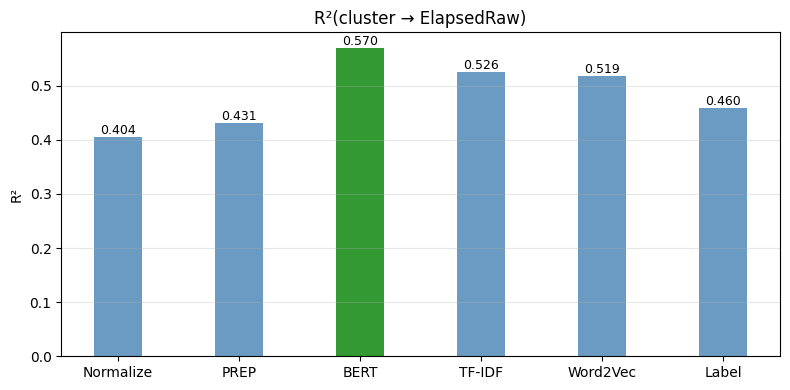

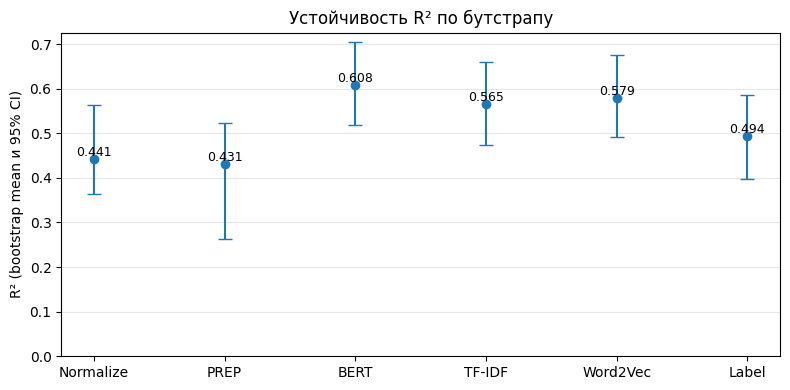

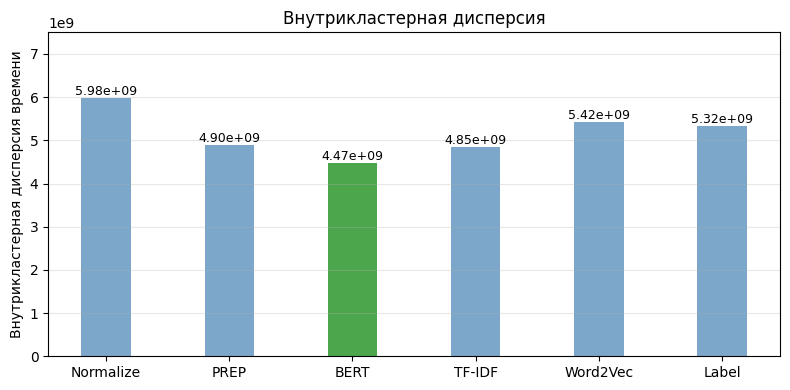

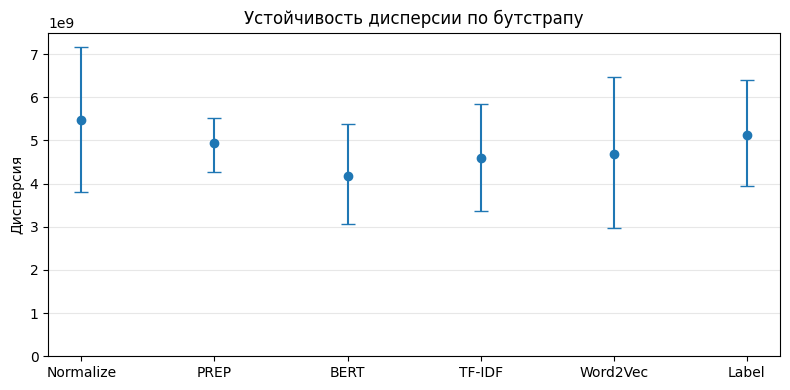

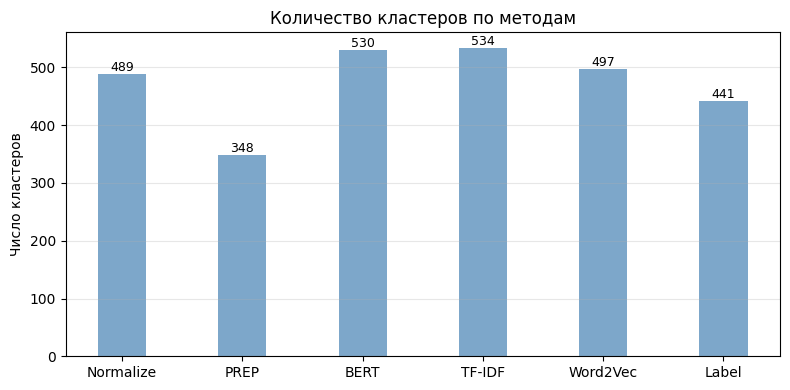

In [ ]:
# Используем рассчитанные метрики из предыдущей ячейки
plot_df = summary_df.copy()

colors_gr = ["steelblue"] * 2 + ["green"] + ["steelblue"] * 3
colors = ["steelblue"] * 6

method_order = [
    "Normalize",
    "PREP",
    "BERT",
    "TF-IDF",
    "Word2Vec",
    "Label",
]

plot_df = plot_df.set_index("Method").loc[method_order].reset_index()

wmiv_mean_bs, wmiv_low_bs, wmiv_high_bs = [], [], []
r2_mean_bs, r2_low_bs, r2_high_bs = [], [], []
mi_mean_bs, mi_low_bs, mi_high_bs = [], [], []

for method in plot_df["Method"]:
    bs = all_results[method]["bootstrap"]

    mean_b, low_b, high_b = summarize_bootstrap(bs, "weighted_mean_intra_var")
    wmiv_mean_bs.append(mean_b)
    wmiv_low_bs.append(low_b)
    wmiv_high_bs.append(high_b)

    mean_b, low_b, high_b = summarize_bootstrap(bs, "r2_cluster_time")
    r2_mean_bs.append(mean_b)
    r2_low_bs.append(low_b)
    r2_high_bs.append(high_b)

    mean_b, low_b, high_b = summarize_bootstrap(bs, "mutual_info_cluster_time")
    mi_mean_bs.append(mean_b)
    mi_low_bs.append(low_b)
    mi_high_bs.append(high_b)

plot_df["r2_mean_bs"] = r2_mean_bs
plot_df["r2_low_bs"] = r2_low_bs
plot_df["r2_high_bs"] = r2_high_bs
plot_df["mi_mean_bs"] = mi_mean_bs
plot_df["mi_low_bs"] = mi_low_bs
plot_df["mi_high_bs"] = mi_high_bs
plot_df["wmiv_mean_bs"] = wmiv_mean_bs
plot_df["wmiv_low_bs"] = wmiv_low_bs
plot_df["wmiv_high_bs"] = wmiv_high_bs

x = np.arange(len(plot_df))
labels = plot_df["Method"].tolist()

# --- График 1: R^2 по методам ---
plt.figure(figsize=(8, 4))
bars = plt.bar(x, plot_df["r2_cluster_time"], color=colors_gr, alpha=0.8, width=0.4)
plt.xticks(x, labels)
plt.ylabel("R²")
plt.title("R²(cluster → ElapsedRaw)")
plt.grid(axis="y", alpha=0.3)
for b, v in zip(bars, plot_df["r2_cluster_time"]):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# --- График 2: R^2 с доверительными интервалами (бутстрап) ---
plt.figure(figsize=(8, 4))
err_low = np.array(plot_df["r2_mean_bs"]) - np.array(plot_df["r2_low_bs"])
err_high = np.array(plot_df["r2_high_bs"]) - np.array(plot_df["r2_mean_bs"])
yerr = np.vstack([err_low, err_high])
plt.errorbar(x, plot_df["r2_mean_bs"], yerr=yerr, fmt="o", capsize=5)
plt.xticks(x, labels)
plt.ylabel("R² (bootstrap mean и 95% CI)")
plt.title("Устойчивость R² по бутстрапу")
plt.grid(axis="y", alpha=0.3)
for xi, v in zip(x, plot_df["r2_mean_bs"]):
    plt.text(xi, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

# --- График 4: Внутрикластерная дисперсия ---
plt.figure(figsize=(8, 4))
bars = plt.bar(x, plot_df["weighted_mean_intra_var"], color=colors_gr, alpha=0.7, width=0.4)
plt.xticks(x, labels)
plt.ylabel("Внутрикластерная дисперсия времени")
plt.title("Внутрикластерная дисперсия")
plt.grid(axis="y", alpha=0.3)
for b, v in zip(bars, plot_df["weighted_mean_intra_var"]):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.2e}", ha="center", va="bottom", fontsize=9)
plt.ylim(bottom=0, top=7500000000)
plt.tight_layout()
plt.show()

# --- График 5: Дисперсия с доверительными интервалами (бутстрап) ---
plt.figure(figsize=(8, 4))
err_low = np.array(plot_df["wmiv_mean_bs"]) - np.array(plot_df["wmiv_low_bs"])
err_high = np.array(plot_df["wmiv_high_bs"]) - np.array(plot_df["wmiv_mean_bs"])
yerr = np.vstack([err_low, err_high])
plt.errorbar(x, plot_df["wmiv_mean_bs"], yerr=yerr, fmt="o", capsize=5)
plt.xticks(x, labels)
plt.ylabel("Дисперсия")
plt.title("Устойчивость дисперсии по бутстрапу")
plt.grid(axis="y", alpha=0.3)
plt.ylim(bottom=0, top=7500000000)
plt.tight_layout()
plt.show()

# --- График 6: Число кластеров ---
plt.figure(figsize=(8, 4))
bars = plt.bar(x, plot_df["n_clusters"], color=colors, alpha=0.7, width=0.4)
plt.xticks(x, labels)
plt.ylabel("Число кластеров")
plt.title("Количество кластеров по методам")
plt.grid(axis="y", alpha=0.3)
for b, v in zip(bars, plot_df["n_clusters"]):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(), f"{int(v)}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ИССЛЕДОВАНИЕ УСТОЙЧИВОСТИ:

stability_rows = []

bert_model_stability = SentenceTransformer("all-MiniLM-L6-v2")

TIME_COL = "ElapsedRaw"
CLUSTER_COL = "PathClusterID"

for run_id in range(1, N_STABILITY_RUNS + 1):
    RANDOM_STATE = run_seed = 42 + run_id

    print("\n" + "=" * 60)
    print(f"STABILITY RUN {run_id} / {N_STABILITY_RUNS} | seed = {run_seed}")
    print("=" * 60)

    # Normalize
    print("[Normalize]")
    labels_normalize, _, _ = cluster_paths_normalization(
        paths,
        df["UID"],
    )

    df_normal_eval = df[[TIME_COL, USER_COL]].copy()
    df_normal_eval[CLUSTER_COL] = labels_normalize
    df_normal_eval = df_normal_eval.dropna()
    df_normal_eval = df_normal_eval[df_normal_eval[CLUSTER_COL] != -1]

    metrics_normal, _ = compute_global_metrics(df_normal_eval)
    stability_rows.append({
        "run_id": run_id,
        "method": "Normalize",
        "weighted_mean_intra_var": metrics_normal["weighted_mean_intra_var"],
        "r2_cluster_time": metrics_normal["r2_cluster_time"],
    })

    # PREP (0-1 matrix)
    print("[PREP (0-1 matrix)]")
    labels_prep_01, _ = cluster_paths_prep_binary(
        paths,
        df["UID"],
        MW=BEST_MW_PREP,
        threshold=BEST_DIST_THRESHOLD,
        show_progress=False
    )

    df_prep_01_eval = df[[TIME_COL, USER_COL]].copy()
    df_prep_01_eval[CLUSTER_COL] = labels_prep_01
    df_prep_01_eval = df_prep_01_eval.dropna()
    df_prep_01_eval = df_prep_01_eval[df_prep_01_eval[CLUSTER_COL] != -1]

    metrics_prep_01, _ = compute_global_metrics(df_prep_01_eval)
    stability_rows.append({
        "run_id": run_id,
        "method": "PREP",
        "weighted_mean_intra_var": metrics_prep_01["weighted_mean_intra_var"],
        "r2_cluster_time": metrics_prep_01["r2_cluster_time"],
    })

    # BERT
    print("[BERT]")
    labels_bert, _, _ = cluster_paths_bert_by_user(
        paths,
        df["UID"],
        model_name="all-MiniLM-L6-v2",
        model=bert_model_stability,
        batch_size=64,
        show_progress=False
    )

    df_bert_eval = df[[TIME_COL, USER_COL]].copy()
    df_bert_eval[CLUSTER_COL] = labels_bert
    df_bert_eval = df_bert_eval.dropna()
    df_bert_eval = df_bert_eval[df_bert_eval[CLUSTER_COL] != -1]

    metrics_bert, _ = compute_global_metrics(df_bert_eval)
    stability_rows.append({
        "run_id": run_id,
        "method": "BERT",
        "weighted_mean_intra_var": metrics_bert["weighted_mean_intra_var"],
        "r2_cluster_time": metrics_bert["r2_cluster_time"],
    })

    # TF-IDF
    print("[TF-IDF]")
    labels_tfidf, _, _ = cluster_paths_tfidf_by_user(
        paths,
        df["UID"],
        max_features=None,
        ngram_range=(1, 1),
        show_progress=False
    )

    df_tfidf_eval = df[[TIME_COL, USER_COL]].copy()
    df_tfidf_eval[CLUSTER_COL] = labels_tfidf
    df_tfidf_eval = df_tfidf_eval.dropna()
    df_tfidf_eval = df_tfidf_eval[df_tfidf_eval[CLUSTER_COL] != -1]

    metrics_tfidf, _ = compute_global_metrics(df_tfidf_eval)
    stability_rows.append({
        "run_id": run_id,
        "method": "TF-IDF",
        "weighted_mean_intra_var": metrics_tfidf["weighted_mean_intra_var"],
        "r2_cluster_time": metrics_tfidf["r2_cluster_time"],
    })

    # Word2Vec
    print("[Word2Vec]")
    labels_w2v, _, _ = cluster_paths_word2vec_by_user(
        paths,
        df["UID"],
        vector_size=100,
        window=3,
        min_count=1,
        sg=1,
        epochs=20,
        workers=1,
        show_progress=False
    )

    df_w2v_eval = df[[TIME_COL, USER_COL]].copy()
    df_w2v_eval[CLUSTER_COL] = labels_w2v
    df_w2v_eval = df_w2v_eval.dropna()
    df_w2v_eval = df_w2v_eval[df_w2v_eval[CLUSTER_COL] != -1]

    metrics_w2v, _ = compute_global_metrics(df_w2v_eval)
    stability_rows.append({
        "run_id": run_id,
        "method": "Word2Vec",
        "weighted_mean_intra_var": metrics_w2v["weighted_mean_intra_var"],
        "r2_cluster_time": metrics_w2v["r2_cluster_time"],
    })


    # Label
    print("[Label]")
    labels_struct, _, _ = cluster_paths_struct_by_user(
        paths,
        df["UID"],
        show_progress=False
    )

    df_struct_eval = df[[TIME_COL, USER_COL]].copy()
    df_struct_eval[CLUSTER_COL] = labels_struct
    df_struct_eval = df_struct_eval.dropna()
    df_struct_eval = df_struct_eval[df_struct_eval[CLUSTER_COL] != -1]

    metrics_struct, _ = compute_global_metrics(df_struct_eval)
    stability_rows.append({
        "run_id": run_id,
        "method": "Label",
        "weighted_mean_intra_var": metrics_struct["weighted_mean_intra_var"],
        "r2_cluster_time": metrics_struct["r2_cluster_time"],
    })

RANDOM_STATE = 42

stability_df = pd.DataFrame(stability_rows)

print("\n=== Результаты 10 запусков ===")
print(stability_df.sort_values(["method", "run_id"]).to_string(index=False))

stability_summary = (
    stability_df
    .groupby("method", as_index=False)
    .agg(
        weighted_mean_intra_var_mean=("weighted_mean_intra_var", "mean"),
        weighted_mean_intra_var_std=("weighted_mean_intra_var", "std"),
        r2_cluster_time_mean=("r2_cluster_time", "mean"),
        r2_cluster_time_std=("r2_cluster_time", "std"),
    )
)

print("\n=== Сводка по устойчивости ===")
print(stability_summary.to_string(index=False))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = stability_summary.copy()

method_order = [
    "Normalize",
    "PREP",
    "BERT",
    "TF-IDF",
    "Word2Vec",
    "Label",
]
plot_df["method"] = pd.Categorical(plot_df["method"], categories=method_order, ordered=True)
plot_df = plot_df.sort_values("method")

def plot_mean_std(df_plot, mean_col, std_col, title, ylabel, fmt="{:.4f}"):
    methods = df_plot["method"].tolist()
    means = df_plot[mean_col].to_numpy(dtype=float)
    stds = df_plot[std_col].fillna(0).to_numpy(dtype=float)

    x = np.arange(len(methods))

    # Цвета точек
    colors = ["steelblue"]*len(methods)

    plt.figure(figsize=(8, 4))

    # errorbar вместо bar
    for xi, mean, std, color in zip(x, means, stds, colors):
        plt.errorbar(
            xi,
            mean,
            yerr=std,
            fmt="o",
            color=color,
            capsize=5
        )

    plt.xticks(x, methods)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)
    plt.ylim(bottom=0, top=7500000000)


    plt.tight_layout()
    plt.show()

plot_mean_std(
    plot_df,
    mean_col="weighted_mean_intra_var_mean",
    std_col="weighted_mean_intra_var_std",
    title="Устойчивость алгоритмов: Дисперсия",
    ylabel="Внутрикластерная дисперсия времени",
    fmt="{:.2f}"
)

plot_mean_std(
    plot_df,
    mean_col="r2_cluster_time_mean",
    std_col="r2_cluster_time_std",
    title="Устойчивость алгоритмов: R²",
    ylabel="R²",
    fmt="{:.4f}"
)

In [ ]:
import pandas as pd

# RUN ALL CLUSTERING METHODS ON NOISY FILES
bert_model_noise = SentenceTransformer("all-MiniLM-L6-v2")

noise_cluster_records = []

for run_id in range(1, N_NOISE_RUNS+1):
    noisy_file = f"noise_inputs/noise_{run_id}.csv"

    print(f"[NOISE RUN {run_id}] {noisy_file}")

    df_noise = pd.read_csv(noisy_file)

    paths_noise = df_noise["WorkDir"].fillna("").astype(str)
    uid_noise = df_noise["UID"]

    # ---------- Normalize ----------
    print(f"[noise {run_id}] Normalize")
    labels_normalize, _, _ = cluster_paths_normalization(
        paths_noise,
        uid_noise,
    )
    df_normalize = df_noise.copy()
    df_normalize["PathClusterID"] = labels_normalize
    out_normalize = os.path.join(NOISE_CLUSTER_DIR, f"noise_{run_id}_normalize.csv")
    df_normalize.to_csv(out_normalize, index=False)

    # ---------- PREP (0-1) ----------
    print(f"[noise {run_id}] PREP (0-1)")
    labels_prep_01, _ = cluster_paths_prep_binary(
        paths_noise,
        uid_noise,
        MW=BEST_MW_PREP,
        threshold=BEST_DIST_THRESHOLD,
        show_progress=False
    )
    df_prep = df_noise.copy()
    df_prep["PathClusterID"] = labels_prep_01
    out_prep = os.path.join(NOISE_CLUSTER_DIR, f"noise_{run_id}_prep_01.csv")
    df_prep.to_csv(out_prep, index=False)

    # ---------- BERT ----------
    print(f"[noise {run_id}] BERT")
    labels_bert, _, _ = cluster_paths_bert_by_user(
        paths_noise,
        uid_noise,
        model_name="all-MiniLM-L6-v2",
        model=bert_model_noise,
        batch_size=64,
        show_progress=False
    )
    df_bert = df_noise.copy()
    df_bert["PathClusterID"] = labels_bert
    out_bert = os.path.join(NOISE_CLUSTER_DIR, f"noise_{run_id}_bert.csv")
    df_bert.to_csv(out_bert, index=False)

    # ---------- TF-IDF ----------
    print(f"[noise {run_id}] TF-IDF")
    labels_tfidf, _, _ = cluster_paths_tfidf_by_user(
        paths_noise,
        uid_noise,
        max_features=None,
        ngram_range=(1, 1),
        show_progress=False
    )
    df_tfidf = df_noise.copy()
    df_tfidf["PathClusterID"] = labels_tfidf
    out_tfidf = os.path.join(NOISE_CLUSTER_DIR, f"noise_{run_id}_tfidf.csv")
    df_tfidf.to_csv(out_tfidf, index=False)

    # ---------- Word2Vec ----------
    print(f"[noise {run_id}] Word2Vec")
    labels_w2v, _, _ = cluster_paths_word2vec_by_user(
        paths_noise,
        uid_noise,
        vector_size=100,
        window=3,
        min_count=1,
        sg=1,
        epochs=20,
        workers=1,
        show_progress=False
    )
    df_w2v = df_noise.copy()
    df_w2v["PathClusterID"] = labels_w2v
    out_w2v = os.path.join(NOISE_CLUSTER_DIR, f"noise_{run_id}_w2v.csv")
    df_w2v.to_csv(out_w2v, index=False)

    # ---------- Label ----------
    print(f"[noise {run_id}] Label")
    labels_struct, _, _ = cluster_paths_struct_by_user(
        paths_noise,
        uid_noise,
        show_progress=False
    )
    df_struct = df_noise.copy()
    df_struct["PathClusterID"] = labels_struct
    out_struct = os.path.join(NOISE_CLUSTER_DIR, f"noise_{run_id}_struct.csv")
    df_struct.to_csv(out_struct, index=False)

    noise_cluster_records.extend([
        {"run_id": run_id, "method": "Normalize", "file": out_prep},
        {"run_id": run_id, "method": "PREP", "file": out_prep},
        {"run_id": run_id, "method": "BERT", "file": out_bert},
        {"run_id": run_id, "method": "TF-IDF", "file": out_tfidf},
        {"run_id": run_id, "method": "Word2Vec", "file": out_w2v},
        {"run_id": run_id, "method": "Label", "file": out_struct},
    ])

noise_cluster_manifest = pd.DataFrame(noise_cluster_records)
noise_cluster_manifest_path = os.path.join(NOISE_CLUSTER_DIR, "noise_cluster_manifest.csv")
noise_cluster_manifest.to_csv(noise_cluster_manifest_path, index=False)

print("\nAll noisy cluster files saved.")
print(noise_cluster_manifest.head(25))

In [ ]:
summary_noise_clusters = []

for _, row in noise_cluster_manifest.iterrows():
    df_tmp = pd.read_csv(row["file"])
    summary_noise_clusters.append({
        "run_id": row["run_id"],
        "method": row["method"],
        "n_clusters": df_tmp["PathClusterID"].nunique(),
        "file": row["file"]
    })

summary_noise_clusters = pd.DataFrame(summary_noise_clusters)
print(summary_noise_clusters.sort_values(["method", "run_id"]))